# 06 · Vapour pressure and phase change

The vapour pressure of a liquid decides whether a storage tank is at atmospheric pressure or at 15 bar, how
much of a solvent evaporates, and at what temperature a mixture boils. This notebook describes it three
ways - Clausius-Clapeyron, the Antoine equation, and an equation of state - and shows what each can do.

**What you will learn**
- derive and use the Clausius-Clapeyron equation
- apply the Antoine equation within its range
- compute saturation properties from an equation of state
- choose storage conditions from the vapour-pressure curve

**Before you start:** notebooks 04-05  ·  **Time:** about 45-60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import components, eos, vapor
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Clausius-Clapeyron: vapour pressure from the heat of vaporisation
Along the saturation line $dp/dT = \Delta H_{vap}/(T\Delta V)$. With an ideal vapour and a negligible liquid volume,
$d\ln p/dT = \Delta H_{vap}/(RT^2)$, and for constant $\Delta H_{vap}$, $\ln p$ is a straight line in $1/T$:

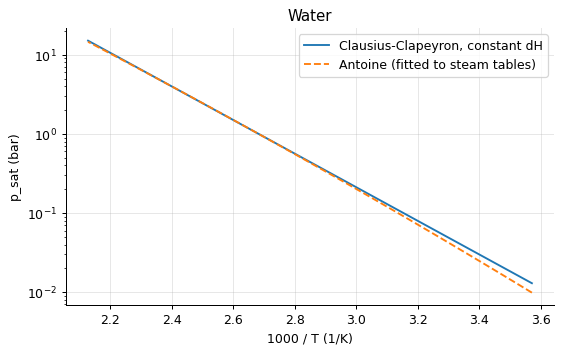

 300.00 K: Clausius-Clapeyron     4.16 kPa, Antoine     3.54 kPa
 373.12 K: Clausius-Clapeyron   101.33 kPa, Antoine   101.18 kPa
 450.00 K: Clausius-Clapeyron   950.32 kPa, Antoine   933.09 kPa


In [2]:
T_ref, p_ref = 373.124, 101325.0                          # water: normal boiling point
dH = 40.65e3                                              # J/mol at 100 degC
Ts = np.linspace(280, 470, 60)
p_cc = vapor.clausius_clapeyron(Ts, p_ref, T_ref, dH)
p_ant = vapor.antoine_psat("water", Ts)
plt.semilogy(1000 / Ts, p_cc / 1e5, label="Clausius-Clapeyron, constant dH"); plt.semilogy(1000 / Ts, p_ant / 1e5, "--", label="Antoine (fitted to steam tables)")
plt.xlabel("1000 / T (1/K)"); plt.ylabel("p_sat (bar)"); plt.title("Water"); plt.legend(); plt.show()
for T in (300.0, 373.124, 450.0):
    print(f"{T:7.2f} K: Clausius-Clapeyron {vapor.clausius_clapeyron(T, p_ref, T_ref, dH)/1e3:8.2f} kPa, Antoine {vapor.antoine_psat('water', T)/1e3:8.2f} kPa")

Above the boiling point Clausius-Clapeyron with one reference point and one heat of vaporisation stays
within 2 %; at 27 degC it is 18 % too high, because the heat of vaporisation of water is larger at low
temperature (44 kJ/mol at 25 degC against 40.7 at 100 degC), so the true line is steeper there. The slope of
$\ln p$ against $1/T$ *is* the heat of vaporisation: a way to measure it from vapour-pressure data alone.

## The Antoine equation
$\ln p = A - B/(T + C)$: three constants per substance, fitted to data. `engthermo`'s constants are fitted to
CoolProp's reference vapour pressures between 1 kPa and 15 bar, with the range and the fit error stored:

In [3]:
for name in ("water", "ethanol", "benzene", "propane", "ammonia"):
    c = components.get(name)
    print(f"{name:<8}: A = {c.antoine[0]:.4f}, B = {c.antoine[1]:8.2f}, C = {c.antoine[2]:8.3f}; valid {c.antoine_range[0]:.0f}-{c.antoine_range[1]:.0f} K, "
          f"max error {c.antoine_fit_error:.1%}; normal boiling point {vapor.antoine_Tsat(name, 101325.0) - 273.15:6.1f} degC")

water   : A = 23.2535, B =  3858.60, C =  -44.141; valid 280-471 K, max error 0.6%; normal boiling point  100.0 degC
ethanol : A = 23.4855, B =  3642.14, C =  -47.093; valid 267-441 K, max error 1.2%; normal boiling point   78.5 degC
benzene : A = 20.8613, B =  2826.35, C =  -50.489; valid 279-476 K, max error 0.5%; normal boiling point   80.1 degC
propane : A = 20.6824, B =  1896.54, C =  -23.921; valid 162-317 K, max error 0.7%; normal boiling point  -42.1 degC
ammonia : A = 22.1036, B =  2229.10, C =  -29.102; valid 196-312 K, max error 0.2%; normal boiling point  -33.3 degC


Antoine is the everyday tool for vapour pressures - but only inside its fitted range. Extrapolating an Antoine
equation towards the critical point or far below 1 kPa can be wrong by large factors.

## Saturation from an equation of state
A cubic equation contains the phase change: at the saturation pressure the liquid and vapour roots have
equal fugacity. Solving that condition gives the vapour pressure, the coexisting volumes and, from the
departure functions, the heat of vaporisation:

In [4]:
rows = []
for T in (230.0, 260.0, 280.0, 295.0):
    s = vapor.eos_psat("pr", "CO2", T)
    rows.append((T, s["p_sat"] / 1e5, s["V_liquid"] * 1e6, s["V_vapor"] * 1e6, s["dH_vap"] / 1e3, vapor.antoine_psat("CO2", T) / 1e5))
print(pd.DataFrame(rows, columns=["T (K)", "p_sat PR (bar)", "V_liq (cm3/mol)", "V_vap (cm3/mol)", "dH_vap (kJ/mol)", "p_sat Antoine (bar)"]).round(2).to_string(index=False))

 T (K)  p_sat PR (bar)  V_liq (cm3/mol)  V_vap (cm3/mol)  dH_vap (kJ/mol)  p_sat Antoine (bar)
 230.0            8.86            37.53          1919.30            14.48                 8.93
 260.0           24.04            43.67           688.49            11.86                24.14
 280.0           41.60            51.68           358.88             9.15                41.15
 295.0           59.97            64.96           206.01             5.81                58.31


The Peng-Robinson vapour pressures agree with the Antoine values within a few percent - remarkable for an
equation whose only inputs are $T_c$, $p_c$ and $\omega$ (the acentric factor was in fact *defined* from the vapour
pressure at $T_r$ = 0.7, which is why cubic equations reproduce it). The heat of vaporisation falls towards the
critical point, where liquid and vapour become identical and it vanishes.

## Application: storage pressure of LPG
Propane is stored as a liquid under its own vapour pressure. The tank must withstand the pressure at the
hottest temperature the tank can reach:

In [5]:
for T_C in (-42, 0, 20, 40, 55):
    T = T_C + 273.15
    print(f"{T_C:4d} degC: vapour pressure of propane {vapor.antoine_psat('propane', T)/1e5:5.2f} bar (PR: {vapor.eos_psat('pr', 'propane', T)['p_sat']/1e5:5.2f} bar)")
print(f"molar enthalpy of vaporisation at 20 degC: {vapor.eos_psat('pr', 'propane', 293.15)['dH_vap']/1e3:.1f} kJ/mol")

 -42 degC: vapour pressure of propane  1.02 bar (PR:  1.02 bar)
   0 degC: vapour pressure of propane  4.76 bar (PR:  4.73 bar)
  20 degC: vapour pressure of propane  8.37 bar (PR:  8.36 bar)
  40 degC: vapour pressure of propane 13.63 bar (PR: 13.72 bar)
  55 degC: vapour pressure of propane 18.83 bar (PR: 19.15 bar)
molar enthalpy of vaporisation at 20 degC: 15.3 kJ/mol


At -42 degC propane boils at atmospheric pressure - refrigerated storage. At ambient temperature the tank sees
8-10 bar, and in the sun up to 20 bar: that is why LPG cylinders are thick-walled and why their design
temperature is set well above the ambient. Every substance's storage strategy - refrigerated, pressurised, or
both - is read off its vapour-pressure curve.

## Inside the algorithm: equal fugacities
At the saturation pressure the liquid and vapour roots of the cubic have the same fugacity. Scan the pressure
and find where $\ln\phi_L - \ln\phi_V$ changes sign:

In [6]:
T = 280.0
pp = np.linspace(35e5, 50e5, 301)
diff = [eos.solve("pr", "CO2", T, p, "liquid")["lnphi"] - eos.solve("pr", "CO2", T, p, "vapor")["lnphi"] for p in pp]
i = np.nonzero(np.diff(np.sign(diff)))[0][0]
print(f"sign change between {pp[i]/1e5:.2f} and {pp[i+1]/1e5:.2f} bar;  library: {vapor.eos_psat('pr', 'CO2', T)['p_sat']/1e5:.3f} bar")

sign change between 41.55 and 41.60 bar;  library: 41.597 bar


## Exercises
1. Trouton's rule states that the molar entropy of vaporisation at the normal boiling point is about 85-88 J/(mol K) for most liquids. Test it with the Antoine-implied heats of vaporisation of benzene, toluene, n-hexane, acetone, ethanol and water. Which substances break the rule, and why?
2. Ammonia is stored as a liquid. Compare the wall pressure for a refrigerated tank at -33 degC with a pressurised tank at 40 degC. Using the enthalpy of vaporisation, estimate the boil-off rate (kg/h) of the refrigerated tank for a heat leak of 5 kW.
3. **Implement it yourself:** fit your own Antoine constants to the vapour pressure of benzene computed with the PR equation between 300 and 500 K (use `scipy.optimize.least_squares` on ln p), and compare with the stored constants.